GEMINI SAYS:

In standard DQN, the target network both selects and evaluates the action:


$$y_t = r_t + \gamma (1 - d_t) \max_a Q(s_{t+1}, a; \theta^-)$$

In Double DQN (DDQN), the **online network** selects the action, while the **target network** evaluates it:


$$a^* = \arg\max_a Q(s_{t+1}, a; \theta)$$

$$y_t = r_t + \gamma (1 - d_t) Q(s_{t+1}, a^*; \theta^-)$$

In [6]:
import gymnasium as gym

from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor
from gymnasium.spaces import Discrete, MultiDiscrete
import numpy as np
import gymnasium as gym
import torch

from pprint import pprint
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from industrial_inventory_env import (
    IndustrialInventoryEnv,
    generate_student_config,
    public_config_summary,
)

np.set_printoptions(suppress=True)

In [2]:
ROLL_NUMBER = "DA25M622"

student_config = generate_student_config(ROLL_NUMBER)
config_summary = public_config_summary(student_config)

print("Assigned configuration generated successfully.")
for key, value in config_summary.items():
    print(f"{key}: {value}")

Assigned configuration generated successfully.
project_version: IITM-6002W-RL-Inventory-2026-v1
roll_number: DA25M622
variant_id: V022
config_fingerprint: 7d77fc79debf206a
demand_multiplier_profile: [1.0, 1.1, 0.9]
initial_inventory_profile: [110, 100, 90]
lead_time_delay_profile: [0.1, 0.0, 0.05]


In [4]:
class DoubleDQN(DQN):
    # (almost all) code is copied from https://github.com/DLR-RM/stable-baselines3/blob/master/stable_baselines3/dqn/dqn.py
    # (since DQN doesn't expose training hooks, we need to copy the whole train function)
    # except a small change
    def train(self, gradient_steps: int, batch_size: int = 100) -> None:
        # Switch to train mode (this affects batch norm / dropout)
        self.policy.set_training_mode(True)
        # Update learning rate according to schedule
        self._update_learning_rate(self.policy.optimizer)

        losses = []
        for _ in range(gradient_steps):
            # Sample replay buffer
            replay_data = self.replay_buffer.sample(batch_size, env=self._vec_normalize_env)  # type: ignore[union-attr]
            # For n-step replay, discount factor is gamma**n_steps (when no early termination)
            discounts = replay_data.discounts if replay_data.discounts is not None else self.gamma

            with torch.no_grad():
                ############# ONLY THESE 2 LINES CHANGED FOR DOUBLE DQN #############
                # Online net selects action
                next_actions = self.q_net(replay_data.next_observations).argmax(
                    dim=1, keepdim=True
                )
                # Target net evaluates that action
                next_q_values = self.q_net_target(replay_data.next_observations).gather(
                    1, next_actions
                )
                #######################################################################

                # Avoid potential broadcast issue
                next_q_values = next_q_values.reshape(-1, 1)
                # 1-step TD target
                target_q_values = replay_data.rewards + (1 - replay_data.dones) * discounts * next_q_values

            # Get current Q-values estimates
            current_q_values = self.q_net(replay_data.observations)

            # Retrieve the q-values for the actions from the replay buffer
            current_q_values = torch.gather(current_q_values, dim=1, index=replay_data.actions.long())

            # Compute Huber loss (less sensitive to outliers)
            loss = F.smooth_l1_loss(current_q_values, target_q_values)
            losses.append(loss.item())

            # Optimize the policy
            self.policy.optimizer.zero_grad()
            loss.backward()
            # Clip gradient norm
            torch.nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)
            self.policy.optimizer.step()

        # Increase update counter
        self._n_updates += gradient_steps

        self.logger.record("train/n_updates", self._n_updates, exclude="tensorboard")
        self.logger.record("train/loss", np.mean(losses))


In [7]:
# copied from dqn_training.ipynb -- only class change: DQN -> DoubleDQN
class FlattenMultiDiscreteActionWrapper(gym.ActionWrapper):
    """Maps a MultiDiscrete action space to a single Discrete space."""

    def __init__(self, env: gym.Env):
        super().__init__(env)
        assert isinstance(
            env.action_space, MultiDiscrete
        ), "Wrapper requires MultiDiscrete action space."
        self.nvec = env.action_space.nvec
        # Total discrete actions = product of all dimensions (11 * 11 * 11 = 1331)
        self.action_space = Discrete(int(np.prod(self.nvec)))

    def action(self, action: int) -> np.ndarray:
        # Decode single integer scalar back into a MultiDiscrete vector
        multi_action = np.unravel_index(action, self.nvec)
        return np.array(multi_action, dtype=self.env.action_space.dtype)


# Wrap your environment creator inside the lambda
env_fn = lambda: FlattenMultiDiscreteActionWrapper(
    IndustrialInventoryEnv(
        student_config=student_config,
        scenario_mode="random",
        domain_randomization=True,
    )
)

# Parallelize across 4 environments
vec_env = make_vec_env(
    env_id=env_fn,
    n_envs=4,
    seed=2026,
)
vec_env = VecMonitor(vec_env)

# NOTE: env defined action space MultiDiscrete([11, 11, 11]) in __init__(), but DQN can't work with it so we map it:
# DQN will now see Discrete(11 * 11 * 11 = 1331) action space instead of MultiDiscrete([11, 11, 11])
# without wrapper, previously got error: AssertionError: The algorithm only supports (<class 'gymnasium.spaces.discrete.Discrete'>,) as action spaces but MultiDiscrete([11 11 11]) was provided
model = DoubleDQN("MultiInputPolicy", vec_env, verbose=1)
model.learn(total_timesteps=25000)

/home/sohang/Projects/iit-madras-web-mtech-ai/trimester3/DA6002W_Online&ReinforcementLearning/ReinforcementLearning/RL_ProjectCompetition/RL_Student_Package_2026/.venv-sb3-torch213/lib/python3.12/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Using cpu device
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 50        |
|    ep_rew_mean      | -8.17e+03 |
|    exploration_rate | 0.924     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 2584      |
|    time_elapsed     | 0         |
|    total_timesteps  | 200       |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss             | 161       |
|    n_updates        | 6         |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 50        |
|    ep_rew_mean      | -7.66e+03 |
|    exploration_rate | 0.848     |
| time/               |           |
|    episodes         | 8         |
|    fps              | 2293      |
|    time_elapsed     | 0         |
|    total_timesteps  | 400       |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss  

In [14]:
model.save("double_dqn_industrial_inventory.zip")

In [15]:
loaded_model = DoubleDQN.load("double_dqn_industrial_inventory.zip")

In [16]:
# manual eval loop for 1 episode, to get the info dict for each step, to get the costs
eval_env = env_fn()
records = []
observation, info = eval_env.reset(seed=2026)
while True:
    # now action is coming single number, not list [int, int, int] as before, because of the wrapper
    action_scalar, _ = loaded_model.predict(observation, deterministic=True)  # MultiDiscrete indices directly
    observation, reward, terminated, truncated, info = eval_env.step(action_scalar)
    records.append({
        "action": eval_env.action(action_scalar),  # convert back to MultiDiscrete indices vector for logging [int, int, int]
        "reward": reward,
        "truncated": truncated,
        "info": info,
        'day': info['day'],
        **info['costs']
    })
    if terminated or truncated:
        break

df = pd.DataFrame(records)
df

,action,reward,truncated,info,day,holding,stockout,ordering,discarding,daily_total,episode_total
0,"[1, 1, 0]",-27.425,False,"{'day': 0, 'demand': [34, 21, 21], 'fulfilled_...",0,2462.5,0.0,280.0,0.0,2742.5,2742.5
1,"[1, 1, 0]",-19.050,False,"{'day': 1, 'demand': [29, 23, 27], 'fulfilled_...",1,1625.0,0.0,280.0,0.0,1905.0,4647.5
2,"[1, 1, 0]",-10.800,False,"{'day': 2, 'demand': [27, 33, 28], 'fulfilled_...",2,800.0,0.0,280.0,0.0,1080.0,5727.5
3,"[1, 1, 0]",-86.500,False,"{'day': 3, 'demand': [42, 25, 25], 'fulfilled_...",3,270.0,8100.0,280.0,0.0,8650.0,14377.5
4,"[1, 1, 0]",-153.800,False,"{'day': 4, 'demand': [26, 28, 29], 'fulfilled_...",4,0.0,15100.0,280.0,0.0,15380.0,29757.5
5,"[2, 8, 10]",-198.000,False,"{'day': 5, 'demand': [22, 23, 27], 'fulfilled_...",5,0.0,19400.0,400.0,0.0,19800.0,49557.5
6,"[1, 1, 0]",-230.800,False,"{'day': 6, 'demand': [28, 25, 27], 'fulfilled_...",6,0.0,22800.0,280.0,0.0,23080.0,72637.5
7,"[5, 8, 3]",-114.550,False,"{'day': 7, 'demand': [34, 21, 24], 'fulfilled_...",7,1455.0,9600.0,400.0,0.0,11455.0,84092.5
8,"[1, 1, 0]",-47.400,False,"{'day': 8, 'demand': [28, 24, 28], 'fulfilled_...",8,1260.0,3200.0,280.0,0.0,4740.0,88832.5
9,"[1, 1, 0]",-157.550,False,"{'day': 9, 'demand': [44, 24, 30], 'fulfilled_...",9,1875.0,13600.0,280.0,0.0,15755.0,104587.5


<Axes: >

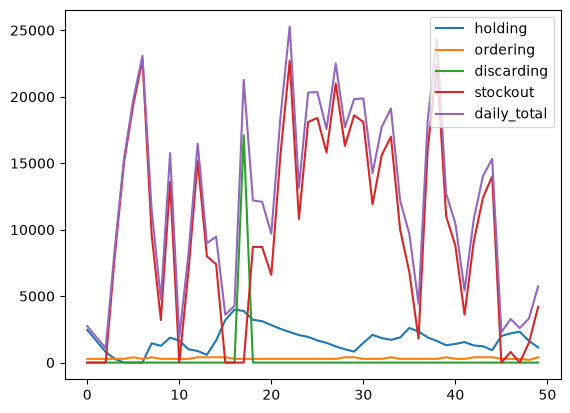

In [17]:
df[['holding', 'ordering', 'discarding', 'stockout', 'daily_total']].plot()      # , 'episode_total'